In [1]:
import pandas as pd
import numpy as np
import joblib
import csv
import os
from sklearn.metrics import (classification_report, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay)
import matplotlib.pyplot as plt

# Charger les splits
(X_train, X_val, X_test,
 y_train, y_val, y_test,
 scaler, feature_names) = joblib.load('../data/processed/splits.pkl')

print(f'Train : {X_train.shape}')
print(f'Val   : {X_val.shape}')
print(f'Test  : {X_test.shape}')

Train : (1942, 32)
Val   : (323, 32)
Test  : (323, 32)


In [2]:
# Fichier de logs des métriques
LOG_FILE = '../reports/metrics_log.csv'
if not os.path.exists(LOG_FILE):
    with open(LOG_FILE, 'w', newline='') as f:
        csv.writer(f).writerow(['model', 'accuracy', 'recall', 'f1', 'auc'])

def log_metrics(name, y_true, y_pred, y_proba):
    report = classification_report(y_true, y_pred, output_dict=True)
    auc    = roc_auc_score(y_true, y_proba)
    with open(LOG_FILE, 'a', newline='') as f:
        csv.writer(f).writerow([
            name,
            round(report['accuracy'], 4),
            round(report['1']['recall'], 4),
            round(report['weighted avg']['f1-score'], 4),
            round(auc, 4)
        ])
    print(f'--- {name} ---')
    print(classification_report(y_true, y_pred, target_names=['Non-Alzheimer', 'Alzheimer']))
    print(f'AUC-ROC : {auc:.4f}')

print('Fonction log_metrics prête')

Fonction log_metrics prête


In [3]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)

log_metrics('LogisticRegression',
    y_val, lr.predict(X_val), lr.predict_proba(X_val)[:, 1])

--- LogisticRegression ---
               precision    recall  f1-score   support

Non-Alzheimer       0.86      0.78      0.82       209
    Alzheimer       0.66      0.77      0.71       114

     accuracy                           0.78       323
    macro avg       0.76      0.78      0.76       323
 weighted avg       0.79      0.78      0.78       323

AUC-ROC : 0.8649


In [4]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

log_metrics('RandomForest',
    y_val, rf.predict(X_val), rf.predict_proba(X_val)[:, 1])

--- RandomForest ---
               precision    recall  f1-score   support

Non-Alzheimer       0.93      0.96      0.94       209
    Alzheimer       0.92      0.87      0.89       114

     accuracy                           0.93       323
    macro avg       0.92      0.91      0.92       323
 weighted avg       0.93      0.93      0.93       323

AUC-ROC : 0.9430


In [5]:
import xgboost as xgb

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=scale_pos, eval_metric='logloss',
    early_stopping_rounds=20, random_state=42, n_jobs=-1
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

log_metrics('XGBoost',
    y_val, xgb_model.predict(X_val), xgb_model.predict_proba(X_val)[:, 1])

joblib.dump(xgb_model, '../models/xgboost_final.pkl')
print('Modèle sauvegardé')

--- XGBoost ---
               precision    recall  f1-score   support

Non-Alzheimer       0.96      0.95      0.95       209
    Alzheimer       0.91      0.92      0.92       114

     accuracy                           0.94       323
    macro avg       0.93      0.94      0.94       323
 weighted avg       0.94      0.94      0.94       323

AUC-ROC : 0.9452
Modèle sauvegardé


=== COMPARAISON DES MODÈLES ===
             model  accuracy  recall     f1    auc
LogisticRegression    0.7771  0.7719 0.7805 0.8649
      RandomForest    0.9257  0.8684 0.9252 0.9430
           XGBoost    0.9412  0.9211 0.9412 0.9452


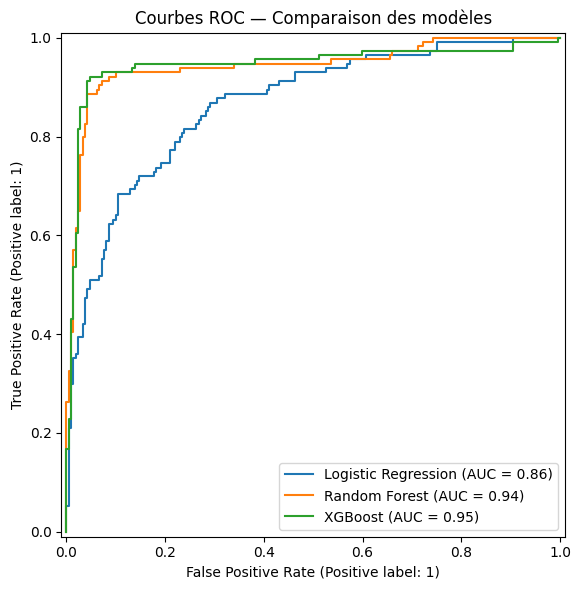

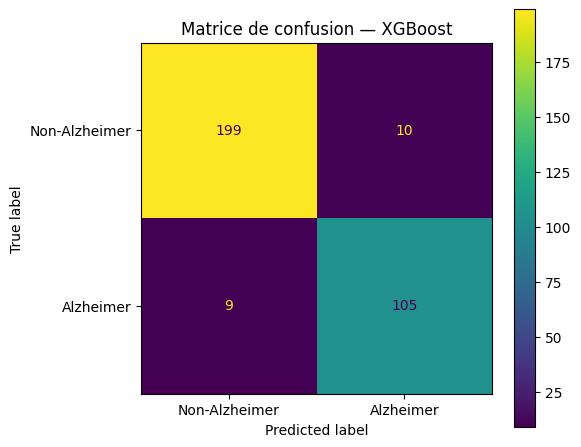

In [6]:
# Tableau comparatif
print("=== COMPARAISON DES MODÈLES ===")
metrics = pd.read_csv('../reports/metrics_log.csv')
print(metrics.to_string(index=False))

# Courbes ROC
fig, ax = plt.subplots(figsize=(8, 6))
for model, name in [(lr, 'Logistic Regression'), 
                    (rf, 'Random Forest'),
                    (xgb_model, 'XGBoost')]:
    RocCurveDisplay.from_estimator(model, X_val, y_val, ax=ax, name=name)
ax.set_title('Courbes ROC — Comparaison des modèles')
plt.tight_layout()
plt.savefig('../reports/roc_curves.png', dpi=150)
plt.show()

# Matrice de confusion XGBoost
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    xgb_model, X_val, y_val,
    display_labels=['Non-Alzheimer', 'Alzheimer'], ax=ax
)
ax.set_title('Matrice de confusion — XGBoost')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png', dpi=150)
plt.show()

In [2]:
import joblib
import pandas as pd
import numpy as np

(X_train, X_val, X_test,
 y_train, y_val, y_test,
 scaler, feature_names) = joblib.load('../data/processed/splits.pkl')

print('Données rechargées OK')


Données rechargées OK


In [3]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import xgboost as xgb

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb_cv = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=scale_pos, eval_metric='logloss',
    random_state=42, n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(xgb_cv, X_train, y_train, cv=cv,
    scoring=['accuracy', 'recall', 'f1', 'roc_auc'])

print('=== VALIDATION CROISÉE 5-FOLD ===')
for metric in ['accuracy', 'recall', 'f1', 'roc_auc']:
    vals = scores[f'test_{metric}']
    print(f'{metric:12} : {vals.mean():.4f} ± {vals.std():.4f}')

=== VALIDATION CROISÉE 5-FOLD ===
accuracy     : 0.9228 ± 0.0123
recall       : 0.9021 ± 0.0261
f1           : 0.9210 ± 0.0138
roc_auc      : 0.9612 ± 0.0109
